## 1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ----Initializing Hyperparameters----
MU_BETA_BASE   = 0.145
MU_GAMMA_BASE  = 0.101
SIGMA_BETA     = 0.05
SIGMA_GAMMA    = 0.03


lambda1 = 0.6
lambda2 = 0.3
lambda3 = 0.1

# ── Training settings ─────────────────────────────────────────────
batch_size = 32
epochs     = 5000

# ── Initialization configs to test ────────────────────────────────
init_configs = [
    (0.1, 0.1),
    (0.5, 0.5),
    (1.0, 1.0),
    (2.0, 2.0),
    (5.0, 5.0),
]

SEEDS = [42, 123, 7]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'Configs : {init_configs}')
print(f'Prior   : mu_beta={MU_BETA_BASE}, sigma_beta={SIGMA_BETA}, '
      f'mu_gamma={MU_GAMMA_BASE}, sigma_gamma={SIGMA_GAMMA}')

Device : cuda
Configs : [(0.1, 0.1), (0.5, 0.5), (1.0, 1.0), (2.0, 2.0), (5.0, 5.0)]
Prior   : mu_beta=0.145, sigma_beta=0.05, mu_gamma=0.101, sigma_gamma=0.03


## 3. Data Loading and Preparation

In [4]:
def load_and_prepare_data(test_frac=0.1, val_frac=0.1):

    data_loaded = pd.read_csv('/content/drive/MyDrive/dengue_thesis/dengue_srilanka_2017.csv')
    data_loaded = data_loaded.sort_values('time').reset_index(drop=True)

#  ------Separate Data into Time, Susceptible, Infected, Recovered----------

    t_all = data_loaded['time'].values.reshape(-1, 1)
    S_all = data_loaded['Susceptible'].values.reshape(-1, 1)
    I_all = data_loaded['Infected'].values.reshape(-1, 1)
    R_all = data_loaded['Recovered'].values.reshape(-1, 1)

 #------Assign value into variable for slipting------

    n       = len(data_loaded)
    n_test  = max(1, int(round(n * test_frac)))
    n_val   = max(1, int(round(n * val_frac)))
    n_train = n - n_test - n_val

 #--------Create Range for Data Preprossing--------

    train_sl = slice(0, n_train)
    val_sl   = slice(n_train, n_train + n_val)
    test_sl  = slice(n_train + n_val, n)

    return (
        t_all[train_sl],  t_all[val_sl],  t_all[test_sl],
        S_all[train_sl],  I_all[train_sl], R_all[train_sl],
        S_all[val_sl],    I_all[val_sl],   R_all[val_sl],
        S_all[test_sl],   I_all[test_sl],  R_all[test_sl]
    )

In [5]:
(t_train_set,     t_val_set,       t_test_set,
 data_S_train_set, data_I_train_set, data_R_train_set,
 data_S_val_set,   data_I_val_set,   data_R_val_set,
 data_S_test_set,  data_I_test_set,  data_R_test_set) = load_and_prepare_data()

print(f'Train: {t_train_set.shape[0]} | Val: {t_val_set.shape[0]} | Test: {t_test_set.shape[0]}')
print(f'Time range -> train: [{t_train_set.min():.0f}, {t_train_set.max():.0f}]  '
      f'val: [{t_val_set.min():.0f}, {t_val_set.max():.0f}]  '
      f'test: [{t_test_set.min():.0f}, {t_test_set.max():.0f}]')

Train: 41 | Val: 5 | Test: 5
Time range -> train: [0, 40]  val: [41, 45]  test: [46, 50]


## 4. Model, Tensor Utilities, DataLoader

In [6]:
from torch.nn.init import xavier_uniform_

class SIRPINN(nn.Module):

    def __init__(self, input_dim=1, hidden_dims=[50, 50, 50], output_dim=3,
                 beta_init=1.0, gamma_init=1.0):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim,    hidden_dims[0]), nn.Tanh(),
            nn.Linear(hidden_dims[0], hidden_dims[1]), nn.Tanh(),
            nn.Linear(hidden_dims[1], hidden_dims[2]), nn.Tanh(),
            nn.Linear(hidden_dims[2], output_dim)
        )

  #----Initializing weight value through Xavier function-----

        for layer in self.network:
            if isinstance(layer, nn.Linear):
                xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0)

  # ----── Initialization under test ──────

        self.params = nn.ParameterDict({
            'beta' : nn.Parameter(torch.tensor(float(beta_init))),
            'gamma': nn.Parameter(torch.tensor(float(gamma_init)))
        })

  #------ Default Function from Pytorch --------

    def forward(self, t):
        return self.network(t)


def to_tensor(x, device, requires_grad=False):
    return torch.tensor(x, dtype=torch.float32,
                        requires_grad=requires_grad).to(device)



#-------- Create Tensor through Pytorch ----------

def prepare_dataloader(t, S, I, R, batch_size, device):
    dataset = TensorDataset(
        to_tensor(t, device, requires_grad=True),
        to_tensor(S, device),
        to_tensor(I, device),
        to_tensor(R, device)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)


print('SIRPINN, to_tensor, prepare_dataloader defined.')

SIRPINN, to_tensor, prepare_dataloader defined.


## 5. Pre-compute Shared Tensors

In [7]:
t_val_tensor        = to_tensor(t_val_set,       device)
data_S_val_tensor   = to_tensor(data_S_val_set,  device)
data_I_val_tensor   = to_tensor(data_I_val_set,  device)
data_R_val_tensor   = to_tensor(data_R_val_set,  device)

t_train_tensor      = to_tensor(t_train_set,      device, requires_grad=True)
data_S_train_tensor = to_tensor(data_S_train_set, device)
data_I_train_tensor = to_tensor(data_I_train_set, device)
data_R_train_tensor = to_tensor(data_R_train_set, device)

t_test_tensor       = to_tensor(t_test_set,       device)

print('All tensors ready.')

All tensors ready.


## 6. Training Functions

In [8]:
def train_standard_pinn(
        model, optimizer, train_loader_local,
        t_val_tensor, data_S_val_tensor, data_I_val_tensor, data_R_val_tensor,
        epochs,
        patience=1500, min_delta=1e-5,
        verbose=False):
    train_losses        = []
    val_losses          = []
    parameter_estimates = {'beta': [], 'gamma': []}
    best_val_loss       = float('inf')
    epochs_without_improvement = 0
    best_model_state    = None
    best_beta=None
    best_gamma=None


  # ------- Train Model --------

    for epoch in range(epochs):
        model.train()
        epoch_batch_losses = []

        for t_batch, S_batch, I_batch, R_batch in train_loader_local:
            optimizer.zero_grad()
            t_batch = t_batch.requires_grad_(True)

            output = model(t_batch)
            S_pred = output[:, 0:1]
            I_pred = output[:, 1:2]
            R_pred = output[:, 2:3]

            beta  = model.params['beta']
            gamma = model.params['gamma']

            dS_dt = torch.autograd.grad(S_pred, t_batch,
                        grad_outputs=torch.ones_like(S_pred), create_graph=True)[0]
            dI_dt = torch.autograd.grad(I_pred, t_batch,
                        grad_outputs=torch.ones_like(I_pred), create_graph=True)[0]
            dR_dt = torch.autograd.grad(R_pred, t_batch,
                        grad_outputs=torch.ones_like(R_pred), create_graph=True)[0]

            physics_loss = (torch.mean((dS_dt + beta * S_pred * I_pred)**2) +
                            torch.mean((dI_dt - beta * S_pred * I_pred + gamma * I_pred)**2) +
                            torch.mean((dR_dt - gamma * I_pred)**2))

            data_loss = (torch.mean((S_pred - S_batch)**2) +
                         torch.mean((I_pred - I_batch)**2) +
                         torch.mean((R_pred - R_batch)**2))

  # --------- Standard PINN: NO prior term --------------

            loss = 0.3 * physics_loss + 0.7 * data_loss
            loss.backward()
            optimizer.step()
            epoch_batch_losses.append(loss.item())

        epoch_train_loss = np.mean(epoch_batch_losses)
        train_losses.append(epoch_train_loss)
        parameter_estimates['beta'].append(model.params['beta'].item())
        parameter_estimates['gamma'].append(model.params['gamma'].item())

        model.eval()
        with torch.no_grad():
            out_val = model(t_val_tensor)
            val_loss = (torch.mean((out_val[:,0:1] - data_S_val_tensor)**2) +
                        torch.mean((out_val[:,1:2] - data_I_val_tensor)**2) +
                        torch.mean((out_val[:,2:3] - data_R_val_tensor)**2)).item()
            val_losses.append(val_loss)

        if val_loss < (best_val_loss - 1e-5):
            best_val_loss = val_loss
            best_beta    = model.params['beta'].item()
            best_gamma   = model.params['gamma'].item()
            epochs_without_improvement = 0
            best_model_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f'    Early stopping at epoch {epoch}  (best val={best_val_loss:.6f}) (Best_beta={best_beta:4f}) (Best_gamme={best_gamma:4f})')
            break

        if verbose and epoch % 500 == 0:
            print(f'    Epoch {epoch:5d} | beta={model.params["beta"].item():.4f} '
                  f'gamma={model.params["gamma"].item():.5f} | val={val_loss:.6f}')

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses, parameter_estimates


def train_with_physics_loss_sir(
        model, optimizer, train_loader_local,
        epochs,
        t_train_tensor, data_S_train_tensor, data_I_train_tensor, data_R_train_tensor,
        t_val_tensor,   data_S_val_tensor,   data_I_val_tensor,   data_R_val_tensor,
        mu_beta_prior, sigma_beta_prior,
        mu_gamma_prior, sigma_gamma_prior,
        lambda1=0.6, lambda2=0.3, lambda3=0.1,
        patience=1500, min_delta=1e-5,
        verbose=False):
    train_losses        = []
    val_losses          = []
    parameter_estimates = {'beta': [], 'gamma': []}
    best_val_loss       = float('inf')
    best_beta          = None
    best_gamma         = None
    epochs_without_improvement = 0
    best_model_state    = None

    for epoch in range(epochs):
        model.train()
        epoch_batch_losses = []

        for t_batch, S_batch, I_batch, R_batch in train_loader_local:
            optimizer.zero_grad()
            t_batch = t_batch.requires_grad_(True)

            output = model(t_batch)
            S_pred = output[:, 0:1]
            I_pred = output[:, 1:2]
            R_pred = output[:, 2:3]

            beta  = model.params['beta']
            gamma = model.params['gamma']

            dS_dt = torch.autograd.grad(S_pred, t_batch,
                        grad_outputs=torch.ones_like(S_pred), create_graph=True)[0]
            dI_dt = torch.autograd.grad(I_pred, t_batch,
                        grad_outputs=torch.ones_like(I_pred), create_graph=True)[0]
            dR_dt = torch.autograd.grad(R_pred, t_batch,
                        grad_outputs=torch.ones_like(R_pred), create_graph=True)[0]

            physics_loss = (torch.mean((dS_dt + beta * S_pred * I_pred)**2) +
                            torch.mean((dI_dt - beta * S_pred * I_pred + gamma * I_pred)**2) +
                            torch.mean((dR_dt - gamma * I_pred)**2))

            data_loss = (torch.mean((S_pred - S_batch)**2) +
                         torch.mean((I_pred - I_batch)**2) +
                         torch.mean((R_pred - R_batch)**2))

            prior_loss = ((beta  - mu_beta_prior )**2 / (2 * sigma_beta_prior**2) +
                          (gamma - mu_gamma_prior)**2 / (2 * sigma_gamma_prior**2))

            loss = lambda2 * physics_loss + lambda1 * data_loss + lambda3 * prior_loss
            loss.backward()
            optimizer.step()
            epoch_batch_losses.append(loss.item())

        epoch_train_loss = np.mean(epoch_batch_losses)
        train_losses.append(epoch_train_loss)
        parameter_estimates['beta'].append(model.params['beta'].item())
        parameter_estimates['gamma'].append(model.params['gamma'].item())

        model.eval()
        with torch.no_grad():
            out_val = model(t_val_tensor)
            val_loss = (torch.mean((out_val[:,0:1] - data_S_val_tensor)**2) +
                        torch.mean((out_val[:,1:2] - data_I_val_tensor)**2) +
                        torch.mean((out_val[:,2:3] - data_R_val_tensor)**2)).item()
            val_losses.append(val_loss)

        if val_loss < (best_val_loss - 1e-5):
            best_val_loss = val_loss
            best_beta    = model.params['beta'].item()
            best_gamma   = model.params['gamma'].item()
            epochs_without_improvement = 0
            best_model_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f'    Early stopping at epoch {epoch} (best val={best_val_loss:.6f}) (Best_beta={best_beta:4f}) (Best_gamme={best_gamma:4f})')
            break

        if verbose and epoch % 500 == 0:
            print(f'    Epoch {epoch:5d} | beta={beta.item():.4f} '
                  f'gamma={gamma.item():.5f} | val={val_loss:.6f}')

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses, parameter_estimates


print('Both training functions defined.')

Both training functions defined.


## 7. Main Experiment Loop

In [9]:
def get_fresh_model_and_optimizer(seed, beta_init, gamma_init):
    torch.manual_seed(seed)
    np.random.seed(seed)
    m   = SIRPINN(input_dim=1, hidden_dims=[50, 50, 50], output_dim=3,
                  beta_init=beta_init, gamma_init=gamma_init).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    return m, opt


def get_fresh_loader(seed):
    torch.manual_seed(seed)
    return prepare_dataloader(
        t_train_set, data_S_train_set, data_I_train_set, data_R_train_set,
        batch_size, device)


def test_rmse(model, t_test_tensor, S_test, I_test, R_test):

    model.eval()
    with torch.no_grad():
        out = model(t_test_tensor).cpu().numpy()
    S_p, I_p, R_p = out[:, 0:1], out[:, 1:2], out[:, 2:3]
    return float(np.sqrt(np.mean((S_p - S_test)**2) +
                         np.mean((I_p - I_test)**2) +
                         np.mean((R_p - R_test)**2)))


# ── Results container ──────────────────────────────────────────────
init_results = []   # one dict per init config

total_runs = len(init_configs) * 2 * len(SEEDS)
run_counter = 0

for (b_init, g_init) in init_configs:

    cfg_label = f'β₀={b_init}, γ₀={g_init}'
    marker    = '← original' if (b_init == 1.0 and g_init == 1.0) else ''
    print(f'\n══ Init Config: {cfg_label}  {marker} ═══════════════════')

    pinn_beta_finals,   pinn_gamma_finals   = [], []
    pipinn_beta_finals, pipinn_gamma_finals = [], []
    pinn_rmses,         pipinn_rmses        = [], []
    pinn_traces_all,    pipinn_traces_all   = [], []

    for seed in SEEDS:

        # ── Standard PINN ────────────────────
        run_counter += 1
        print(f'  [{run_counter}/{total_runs}] Standard PINN  '
              f'| init=({b_init},{g_init}) | seed={seed}')

        m_p, opt_p = get_fresh_model_and_optimizer(seed, b_init, g_init)
        loader_p   = get_fresh_loader(seed)

        _, _, p_est_p = train_standard_pinn(
            model=m_p, optimizer=opt_p, train_loader_local=loader_p,
            t_val_tensor=t_val_tensor,
            data_S_val_tensor=data_S_val_tensor,
            data_I_val_tensor=data_I_val_tensor,
            data_R_val_tensor=data_R_val_tensor,
            epochs=epochs,
            verbose=True
        )

        fb_p = m_p.params['beta'].item()
        fg_p = m_p.params['gamma'].item()
        pinn_beta_finals.append(fb_p)
        pinn_gamma_finals.append(fg_p)
        pinn_rmses.append(test_rmse(m_p, t_test_tensor,
                                     data_S_test_set, data_I_test_set, data_R_test_set))
        pinn_traces_all.append(p_est_p)

        # ── PI-PINN ───────────
        run_counter += 1
        print(f'  [{run_counter}/{total_runs}] PI-PINN (Ours) '
              f'| init=({b_init},{g_init}) | seed={seed}')

        m_pi, opt_pi = get_fresh_model_and_optimizer(seed, b_init, g_init)
        loader_pi    = get_fresh_loader(seed)

        _, _, p_est_pi = train_with_physics_loss_sir(
            model=m_pi, optimizer=opt_pi, train_loader_local=loader_pi,
            epochs=epochs,
            t_train_tensor=t_train_tensor,
            data_S_train_tensor=data_S_train_tensor,
            data_I_train_tensor=data_I_train_tensor,
            data_R_train_tensor=data_R_train_tensor,
            t_val_tensor=t_val_tensor,
            data_S_val_tensor=data_S_val_tensor,
            data_I_val_tensor=data_I_val_tensor,
            data_R_val_tensor=data_R_val_tensor,
            mu_beta_prior=MU_BETA_BASE,   sigma_beta_prior=SIGMA_BETA,
            mu_gamma_prior=MU_GAMMA_BASE, sigma_gamma_prior=SIGMA_GAMMA,
            lambda1=lambda1, lambda2=lambda2, lambda3=lambda3,
            verbose=True
        )

        fb_pi = m_pi.params['beta'].item()
        fg_pi = m_pi.params['gamma'].item()
        pipinn_beta_finals.append(fb_pi)
        pipinn_gamma_finals.append(fg_pi)
        pipinn_rmses.append(test_rmse(m_pi, t_test_tensor,
                                       data_S_test_set, data_I_test_set, data_R_test_set))
        pipinn_traces_all.append(p_est_pi)

    def _r0_list(betas, gammas):
        return [b / g for b, g in zip(betas, gammas)]

    init_results.append({
        'b_init'            : b_init,
        'g_init'            : g_init,
        'label'             : cfg_label,
        'is_original'       : (b_init == 1.0 and g_init == 1.0),

        # Standard PINN — raw estimates (no ground truth to compare against)
        'pinn_beta_mean'    : np.mean(pinn_beta_finals),
        'pinn_beta_std'     : np.std(pinn_beta_finals),
        'pinn_gamma_mean'   : np.mean(pinn_gamma_finals),
        'pinn_gamma_std'    : np.std(pinn_gamma_finals),
        'pinn_r0_mean'      : np.mean(_r0_list(pinn_beta_finals, pinn_gamma_finals)),
        'pinn_rmse_mean'    : np.mean(pinn_rmses),

        # PI-PINN
        'pipinn_beta_mean'  : np.mean(pipinn_beta_finals),
        'pipinn_beta_std'   : np.std(pipinn_beta_finals),
        'pipinn_gamma_mean' : np.mean(pipinn_gamma_finals),
        'pipinn_gamma_std'  : np.std(pipinn_gamma_finals),
        'pipinn_r0_mean'    : np.mean(_r0_list(pipinn_beta_finals, pipinn_gamma_finals)),
        'pipinn_rmse_mean'  : np.mean(pipinn_rmses),

        # Traces for convergence plots
        'pinn_traces'       : pinn_traces_all,
        'pipinn_traces'     : pipinn_traces_all,
    })

# ── Cross-init consistency — the robustness metric for real data ──
pinn_beta_across_inits    = [r['pinn_beta_mean']    for r in init_results]
pipinn_beta_across_inits  = [r['pipinn_beta_mean']  for r in init_results]
pinn_gamma_across_inits   = [r['pinn_gamma_mean']   for r in init_results]
pipinn_gamma_across_inits = [r['pipinn_gamma_mean'] for r in init_results]

print('\n Initialization sensitivity experiment complete (real dengue data).')
print(f' Cross-init std, Standard PINN  : beta={np.std(pinn_beta_across_inits):.4f}, '
      f'gamma={np.std(pinn_gamma_across_inits):.4f}')
print(f' Cross-init std, PI-PINN (Ours) : beta={np.std(pipinn_beta_across_inits):.4f}, '
      f'gamma={np.std(pipinn_gamma_across_inits):.4f}')
print(' Lower cross-init std = more consistent convergence regardless of starting point.')


══ Init Config: β₀=0.1, γ₀=0.1   ═══════════════════
  [1/30] Standard PINN  | init=(0.1,0.1) | seed=42
    Epoch     0 | beta=0.0980 gamma=0.09800 | val=3.540008
    Epoch   500 | beta=0.0633 gamma=0.08248 | val=0.000133
    Epoch  1000 | beta=0.0664 gamma=0.08850 | val=0.000140
    Epoch  1500 | beta=0.0735 gamma=0.09704 | val=0.000054
    Epoch  2000 | beta=0.0848 gamma=0.10598 | val=0.000030
    Epoch  2500 | beta=0.1002 gamma=0.11375 | val=0.000667
    Epoch  3000 | beta=0.1250 gamma=0.13365 | val=0.000043
    Early stopping at epoch 3014  (best val=0.000008) (Best_beta=0.073812) (Best_gamme=0.097374)
  [2/30] PI-PINN (Ours) | init=(0.1,0.1) | seed=42
    Epoch     0 | beta=0.1020 gamma=0.10159 | val=3.538952
    Epoch   500 | beta=0.1450 gamma=0.10100 | val=0.000133
    Epoch  1000 | beta=0.1450 gamma=0.10100 | val=0.000141
    Epoch  1500 | beta=0.1450 gamma=0.10099 | val=0.000052
    Epoch  2000 | beta=0.1450 gamma=0.10100 | val=0.000030
    Epoch  2500 | beta=0.1450 gamma=0.1

## 9. Figure A — Bar Chart: Estimated Parameters Across Init Configs

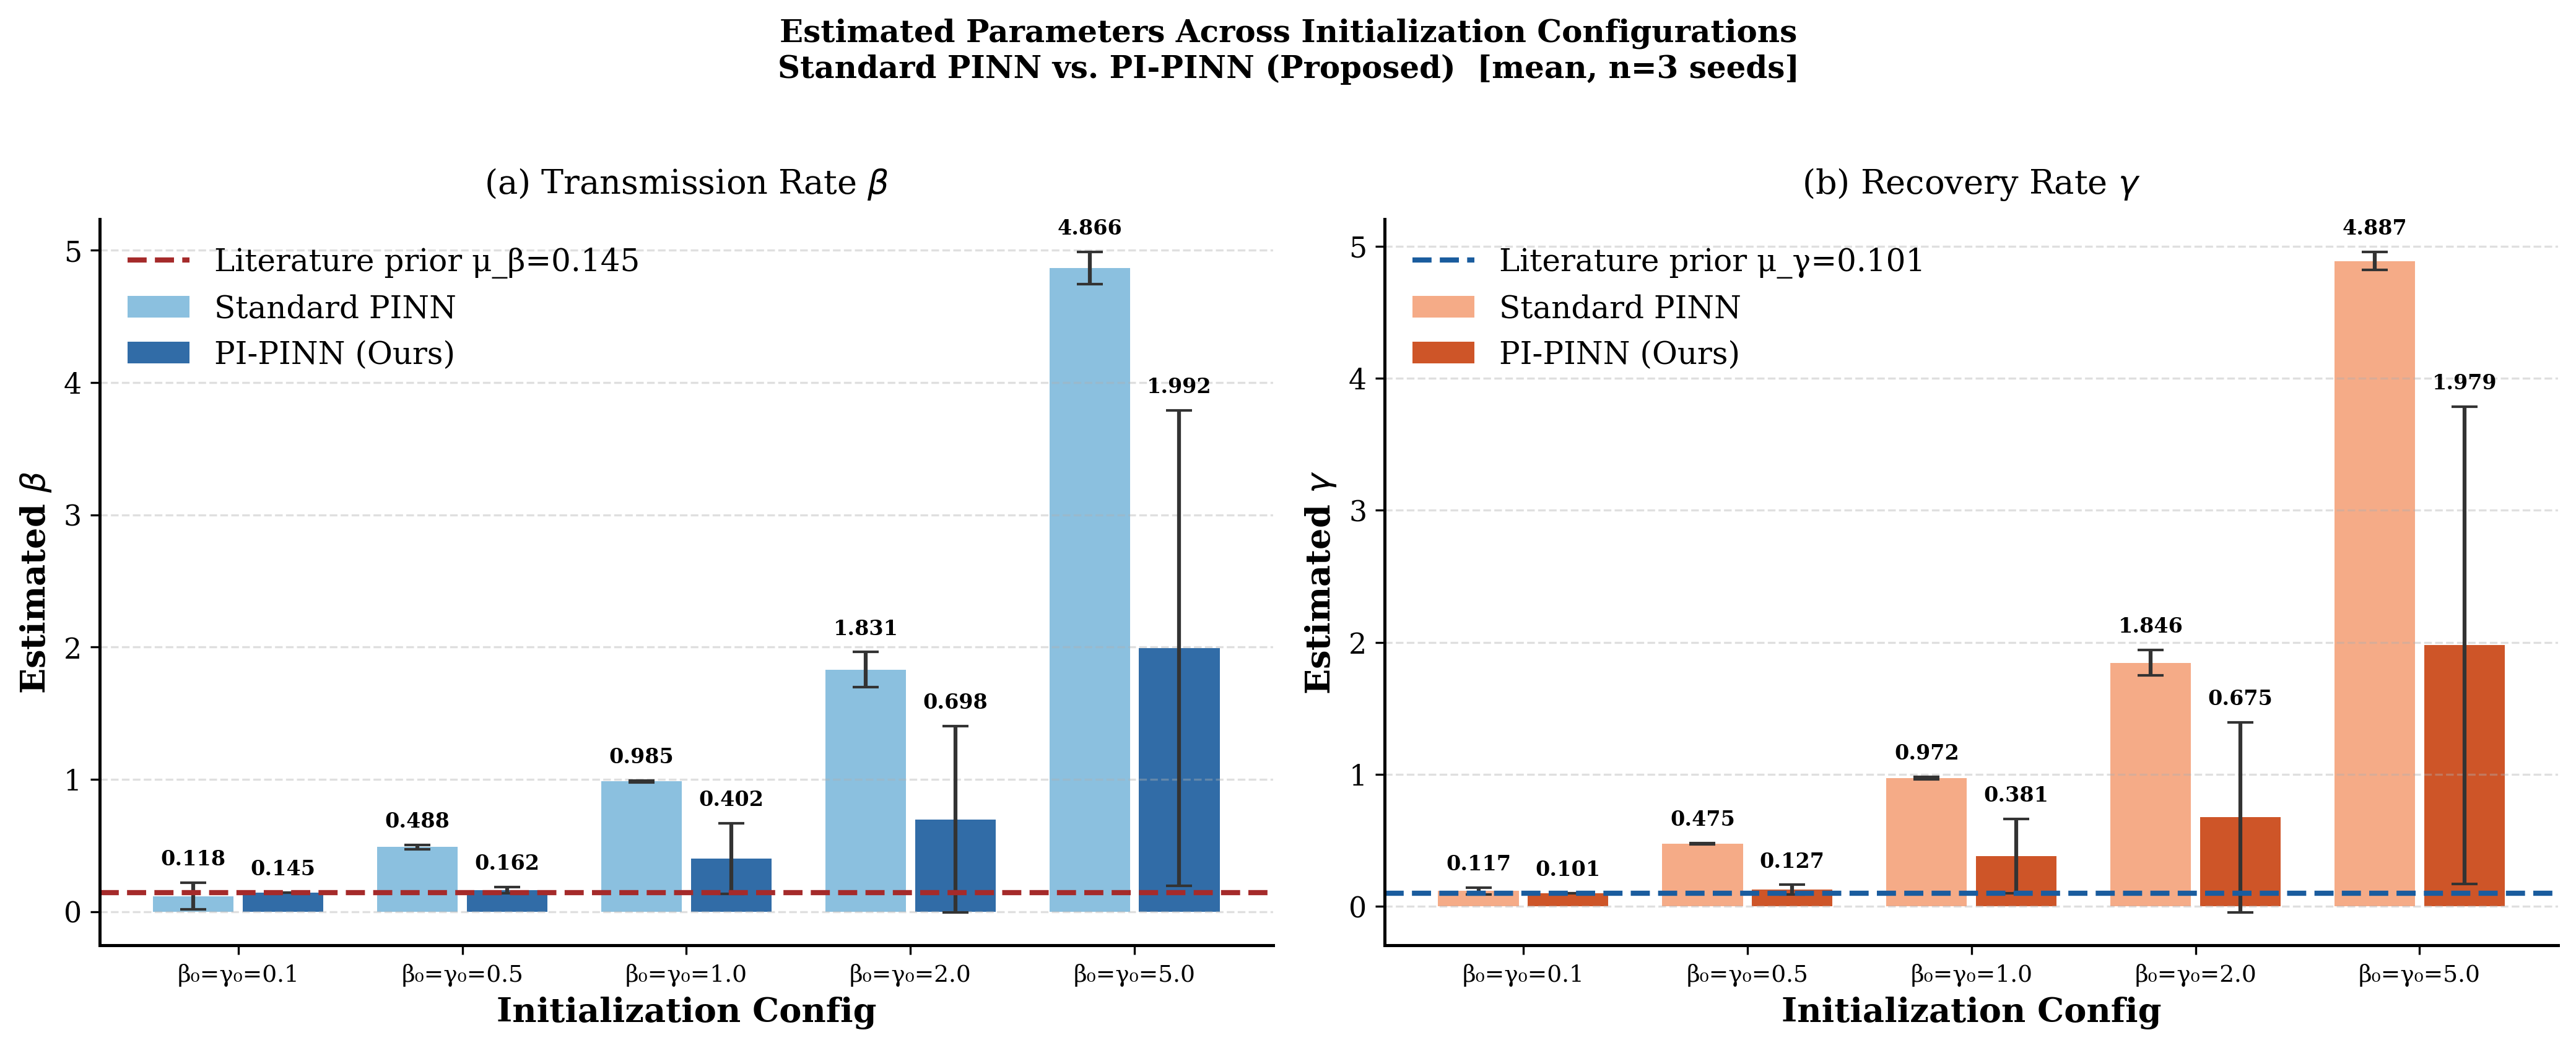

Saved: Fig_Init_Sensitivity_Bar_RealData.png


In [10]:
plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.labelsize' : 13,
    'axes.titlesize' : 13,
    'legend.fontsize': 10,
    'axes.linewidth' : 1.2,
})

x_labels = [f'β₀=γ₀={r["b_init"]}' for r in init_results]
x        = np.arange(len(x_labels))
w        = 0.20

pinn_bm  = [r['pinn_beta_mean']    for r in init_results]
pinn_bs  = [r['pinn_beta_std']     for r in init_results]
pinn_gm  = [r['pinn_gamma_mean']   for r in init_results]
pinn_gs  = [r['pinn_gamma_std']    for r in init_results]
pi_bm    = [r['pipinn_beta_mean']  for r in init_results]
pi_bs    = [r['pipinn_beta_std']   for r in init_results]
pi_gm    = [r['pipinn_gamma_mean'] for r in init_results]
pi_gs    = [r['pipinn_gamma_std']  for r in init_results]

C_PINN_B   = '#7fbadc'
C_PINN_G   = '#f4a27a'
C_PIPINN_B = '#1a5c9e'
C_PIPINN_G = '#c94210'
err_kw     = dict(capsize=5, error_kw={'linewidth': 1.5, 'ecolor': '#333333'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)

# ── Left: Beta ────────────────────────────────────────────────────
ax = axes[0]
b1 = ax.bar(x - w, pinn_bm, w*1.8, yerr=pinn_bs, label='Standard PINN',
             color=C_PINN_B, alpha=0.9, **err_kw)
b2 = ax.bar(x + w, pi_bm,   w*1.8, yerr=pi_bs,   label='PI-PINN (Ours)',
             color=C_PIPINN_B, alpha=0.9, **err_kw)

y_range = max(pinn_bm) + max(pinn_bs)
pad     = y_range * 0.02

for bar, err in zip(b1, pinn_bs):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h + err + pad,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8,fontweight='bold')

for bar, err in zip(b2, pi_bs):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h + err + pad,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8,fontweight='bold')


ax.axhline(MU_BETA_BASE, color='brown', linestyle='--', linewidth=2,
           label=f'Literature prior μ_β={MU_BETA_BASE}')



ax.set_xlabel('Initialization Config', fontweight='bold')
ax.set_ylabel(r'Estimated $\beta$', fontweight='bold')
ax.set_title(r'(a) Transmission Rate $\beta$', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=9)
ax.legend(frameon=False, fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── Right: Gamma ──────────────────────────────────────────────────
ax = axes[1]
b3 = ax.bar(x - w, pinn_gm, w*1.8, yerr=pinn_gs, label='Standard PINN',
             color=C_PINN_G, alpha=0.9, **err_kw)
b4 = ax.bar(x + w, pi_gm,   w*1.8, yerr=pi_gs,   label='PI-PINN (Ours)',
             color=C_PIPINN_G, alpha=0.9, **err_kw)

y_range = max(pinn_gm) + max(pinn_gs)
pad     = y_range * 0.02

for bar, err in zip(b3, pinn_gs):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h + err + pad,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8,fontweight='bold')

for bar, err in zip(b4, pi_gs):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h + err + pad,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8,fontweight='bold')

ax.axhline(MU_GAMMA_BASE, color=C_PIPINN_B, linestyle='--', linewidth=2,
           label=f'Literature prior μ_γ={MU_GAMMA_BASE}')


ax.set_xlabel('Initialization Config', fontweight='bold')
ax.set_ylabel(r'Estimated $\gamma$', fontweight='bold')
ax.set_title(r'(b) Recovery Rate $\gamma$', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=9)
ax.legend(frameon=False, fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(
    'Estimated Parameters Across Initialization Configurations\n'
    'Standard PINN vs. PI-PINN (Proposed)  [mean, n=3 seeds]',
    fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('Fig_Init_Sensitivity_Bar_RealData.png', dpi=500, bbox_inches='tight')
plt.show()
print('Saved: Fig_Init_Sensitivity_Bar_RealData.png')

## 10. Figure B — Convergence Panel (Real Data; prior shown instead of ground truth)

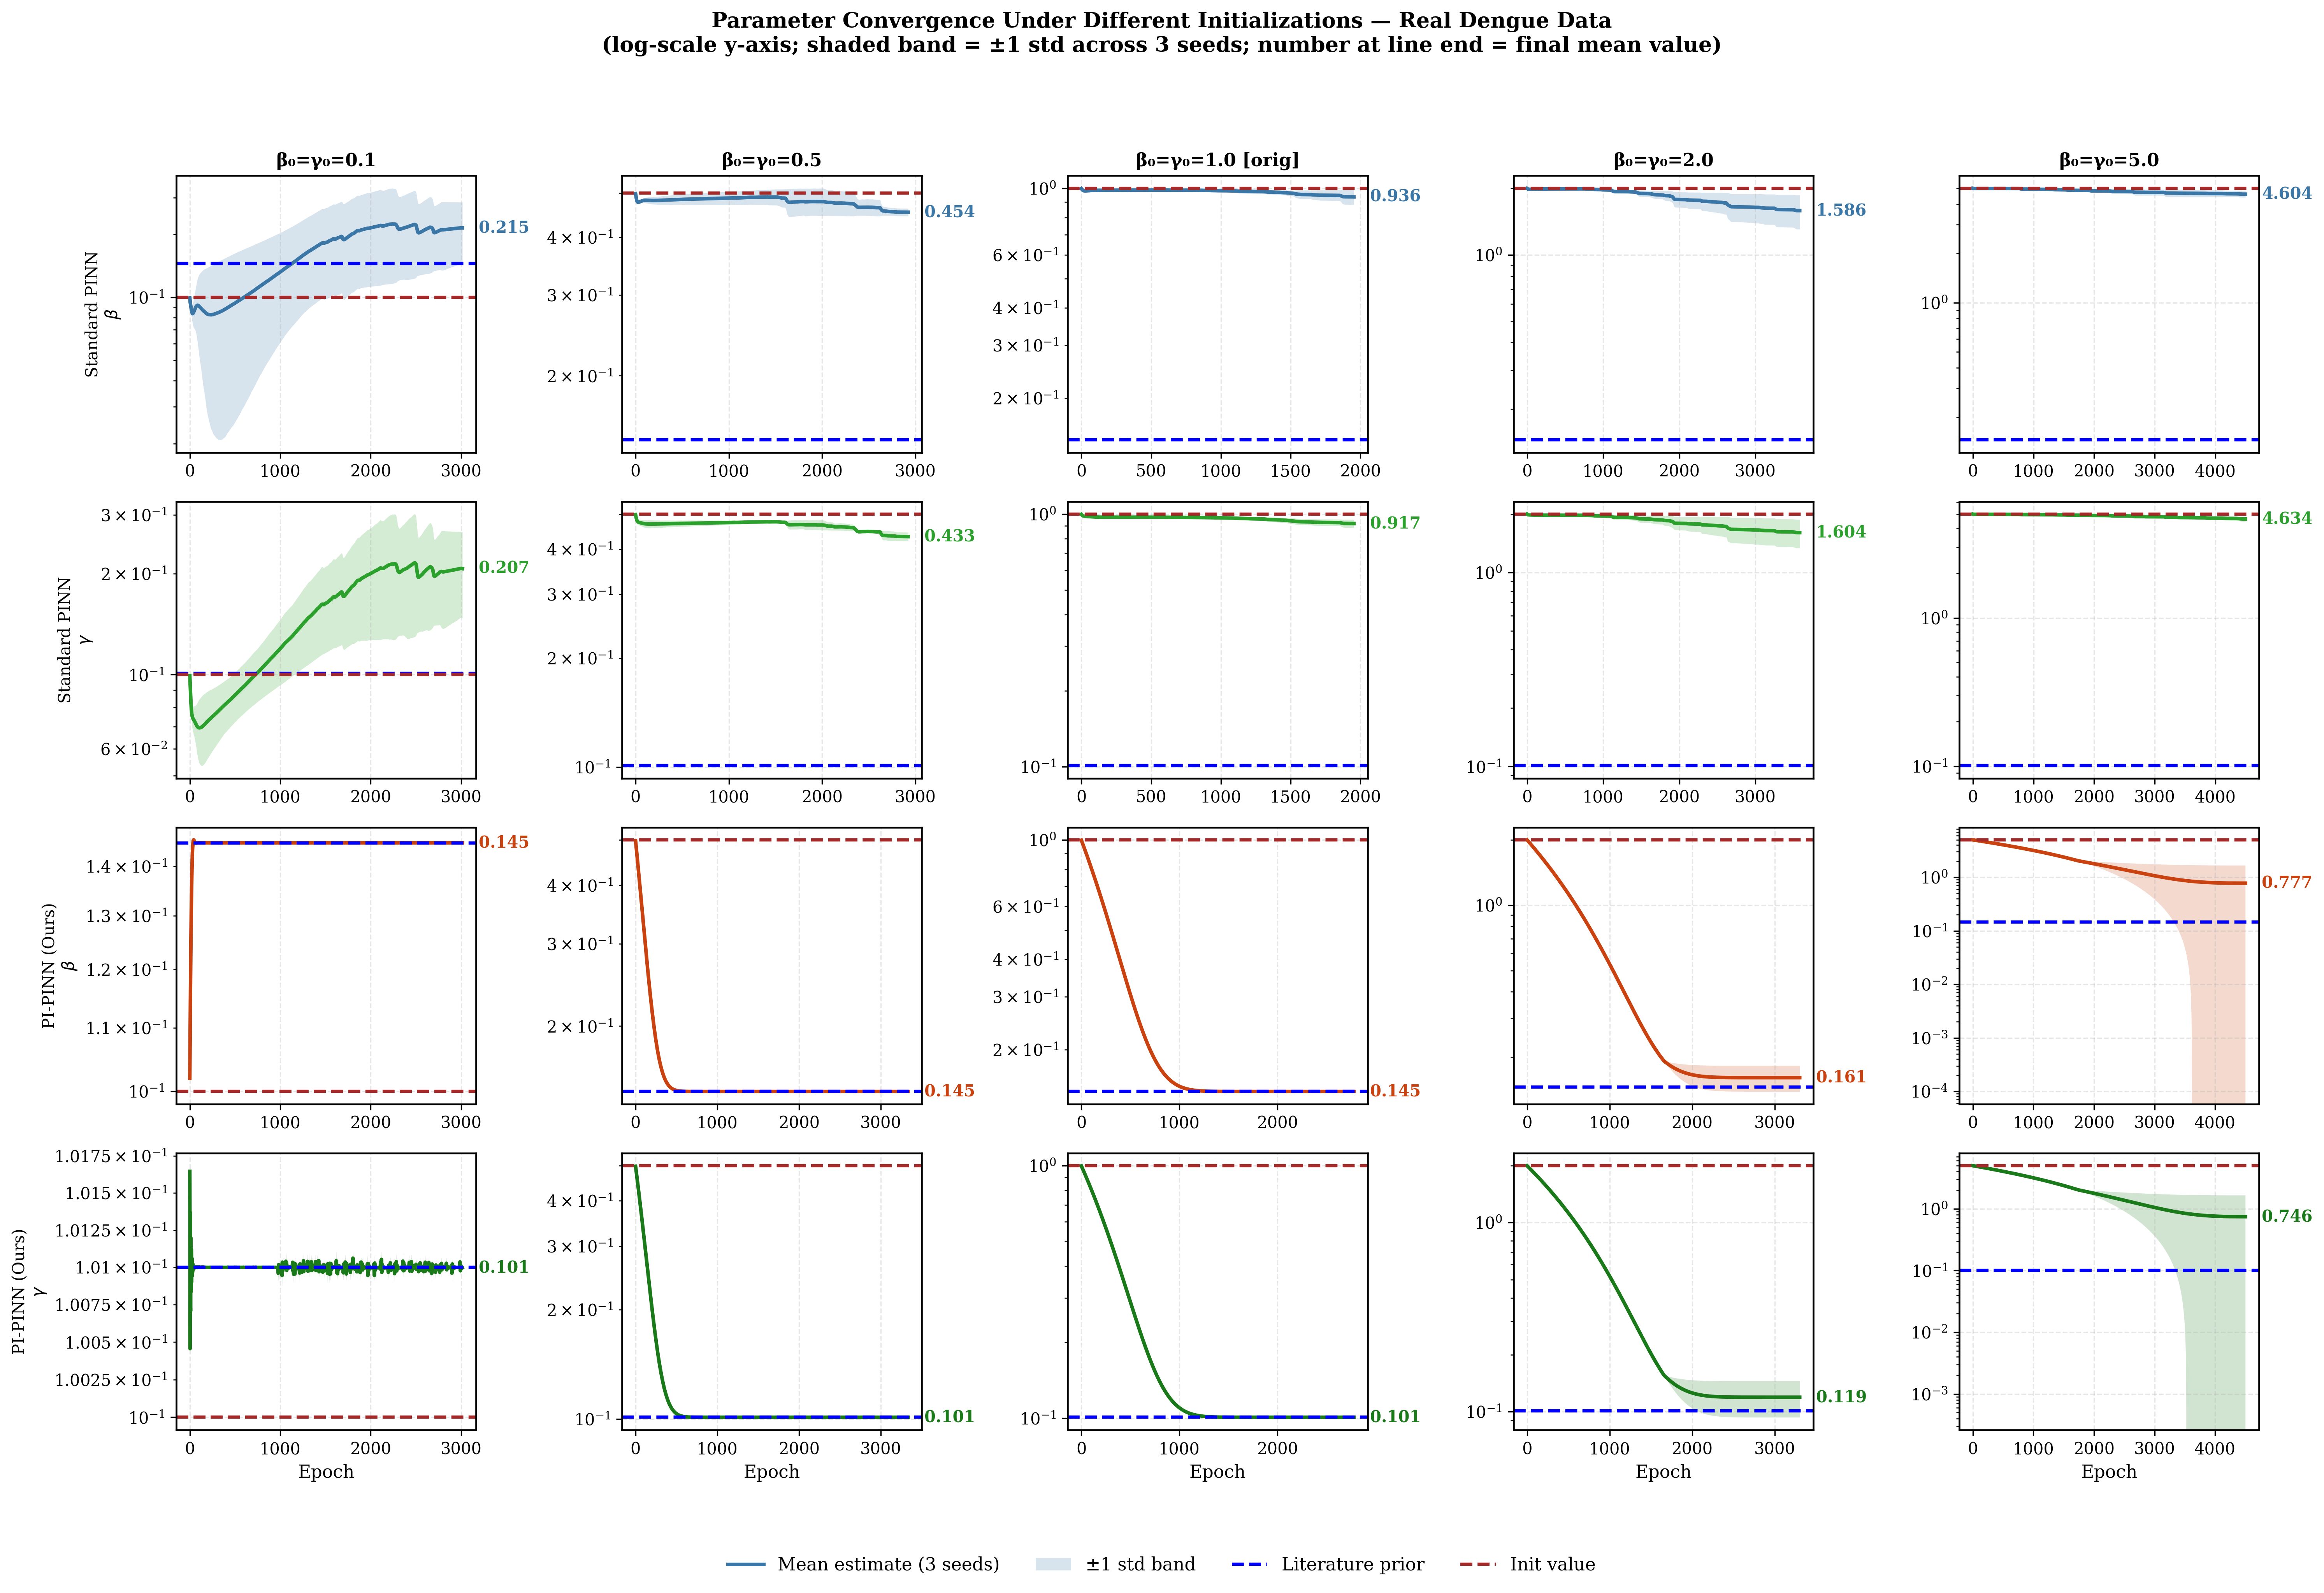

Saved: Fig_Init_Convergence_Panel_RealData_clean.png


In [11]:

plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 10,
    'axes.labelsize' : 11,
    'axes.titlesize' : 11,
    'legend.fontsize': 10,
    'axes.linewidth' : 1.1,
})

def forward_fill_matrix(traces, key):
    max_len = max(len(tr[key]) for tr in traces)
    mat = np.full((len(traces), max_len), np.nan)
    for i, tr in enumerate(traces):
        vals = tr[key]
        mat[i, :len(vals)] = vals
        mat[i, len(vals):] = vals[-1]
    return max_len, np.nanmean(mat, axis=0), np.nanstd(mat, axis=0)

row_specs = [
    ('pinn_traces',   'beta',  'Standard PINN',  r'$\beta$', '#3a76a6', MU_BETA_BASE),
    ('pinn_traces',   'gamma', 'Standard PINN',  r'$\gamma$', '#2ca02c', MU_GAMMA_BASE),
    ('pipinn_traces', 'beta',  'PI-PINN (Ours)', r'$\beta$', '#c94210', MU_BETA_BASE),
    ('pipinn_traces', 'gamma', 'PI-PINN (Ours)', r'$\gamma$', '#1a7a1a', MU_GAMMA_BASE),
]

fig, axes = plt.subplots(len(row_specs), len(init_configs),
                          figsize=(20, 13), dpi=300, sharex=False)

legend_handles, legend_labels = [], []

for row, (trace_key, param, model_name, sym, color, prior_val) in enumerate(row_specs):
    for col, r in enumerate(init_results):
        ax       = axes[row, col]
        traces   = r[trace_key]
        init_val = r['b_init'] if param == 'beta' else r['g_init']

        max_len, mean_vals, std_vals = forward_fill_matrix(traces, param)
        ep = np.arange(max_len)

        # shaded uncertainty band (replaces messy individual lines)
        band = ax.fill_between(ep, mean_vals - std_vals, mean_vals + std_vals,
                                 color=color, alpha=0.20, linewidth=0)

        # single clean mean line
        mean_line, = ax.plot(ep, mean_vals, color=color, linewidth=2.2)

        # reference lines
        prior_line = ax.axhline(prior_val, color='blue', linestyle='--', linewidth=2)
        init_line  = ax.axhline(init_val,  color='brown', linestyle='--',
                                 linewidth=2)

        # final value annotated directly on the plot (no need to read legend)
        final_val = mean_vals[-1]
        ax.annotate(f'{final_val:.3f}', xy=(ep[-1], final_val),
                     xytext=(10, 0), textcoords='offset points',
                     fontsize=10, color=color, fontweight='bold', va='center')

        if row == 0 and col == 0:
            legend_handles += [mean_line, band, prior_line, init_line]
            legend_labels  += ['Mean estimate (3 seeds)', '±1 std band',
                                'Literature prior', 'Init value']

        ax.set_yscale('log')
        ax.grid(True, which='major', linestyle='--', alpha=0.3)

        title_tag = ' [orig]' if r['is_original'] else ''
        if row == 0:
            ax.set_title(f'β₀=γ₀={r["b_init"]}{title_tag}', fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{model_name}\n{sym}', fontsize=10)
        if row == len(row_specs) - 1:
            ax.set_xlabel('Epoch')

fig.suptitle('Parameter Convergence Under Different Initializations — Real Dengue Data\n'
              '(log-scale y-axis; shaded band = ±1 std across 3 seeds; '
              'number at line end = final mean value)',
              fontsize=13, fontweight='bold', y=1.01)

fig.legend(legend_handles, legend_labels, loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, -0.03), frameon=False, fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('Fig_Init_Convergence_Panel_RealData_clean.png', dpi=500, bbox_inches='tight')
plt.show()
print('Saved: Fig_Init_Convergence_Panel_RealData_clean.png')

## 11. Figure C — Heatmap: Estimated Parameters Overview

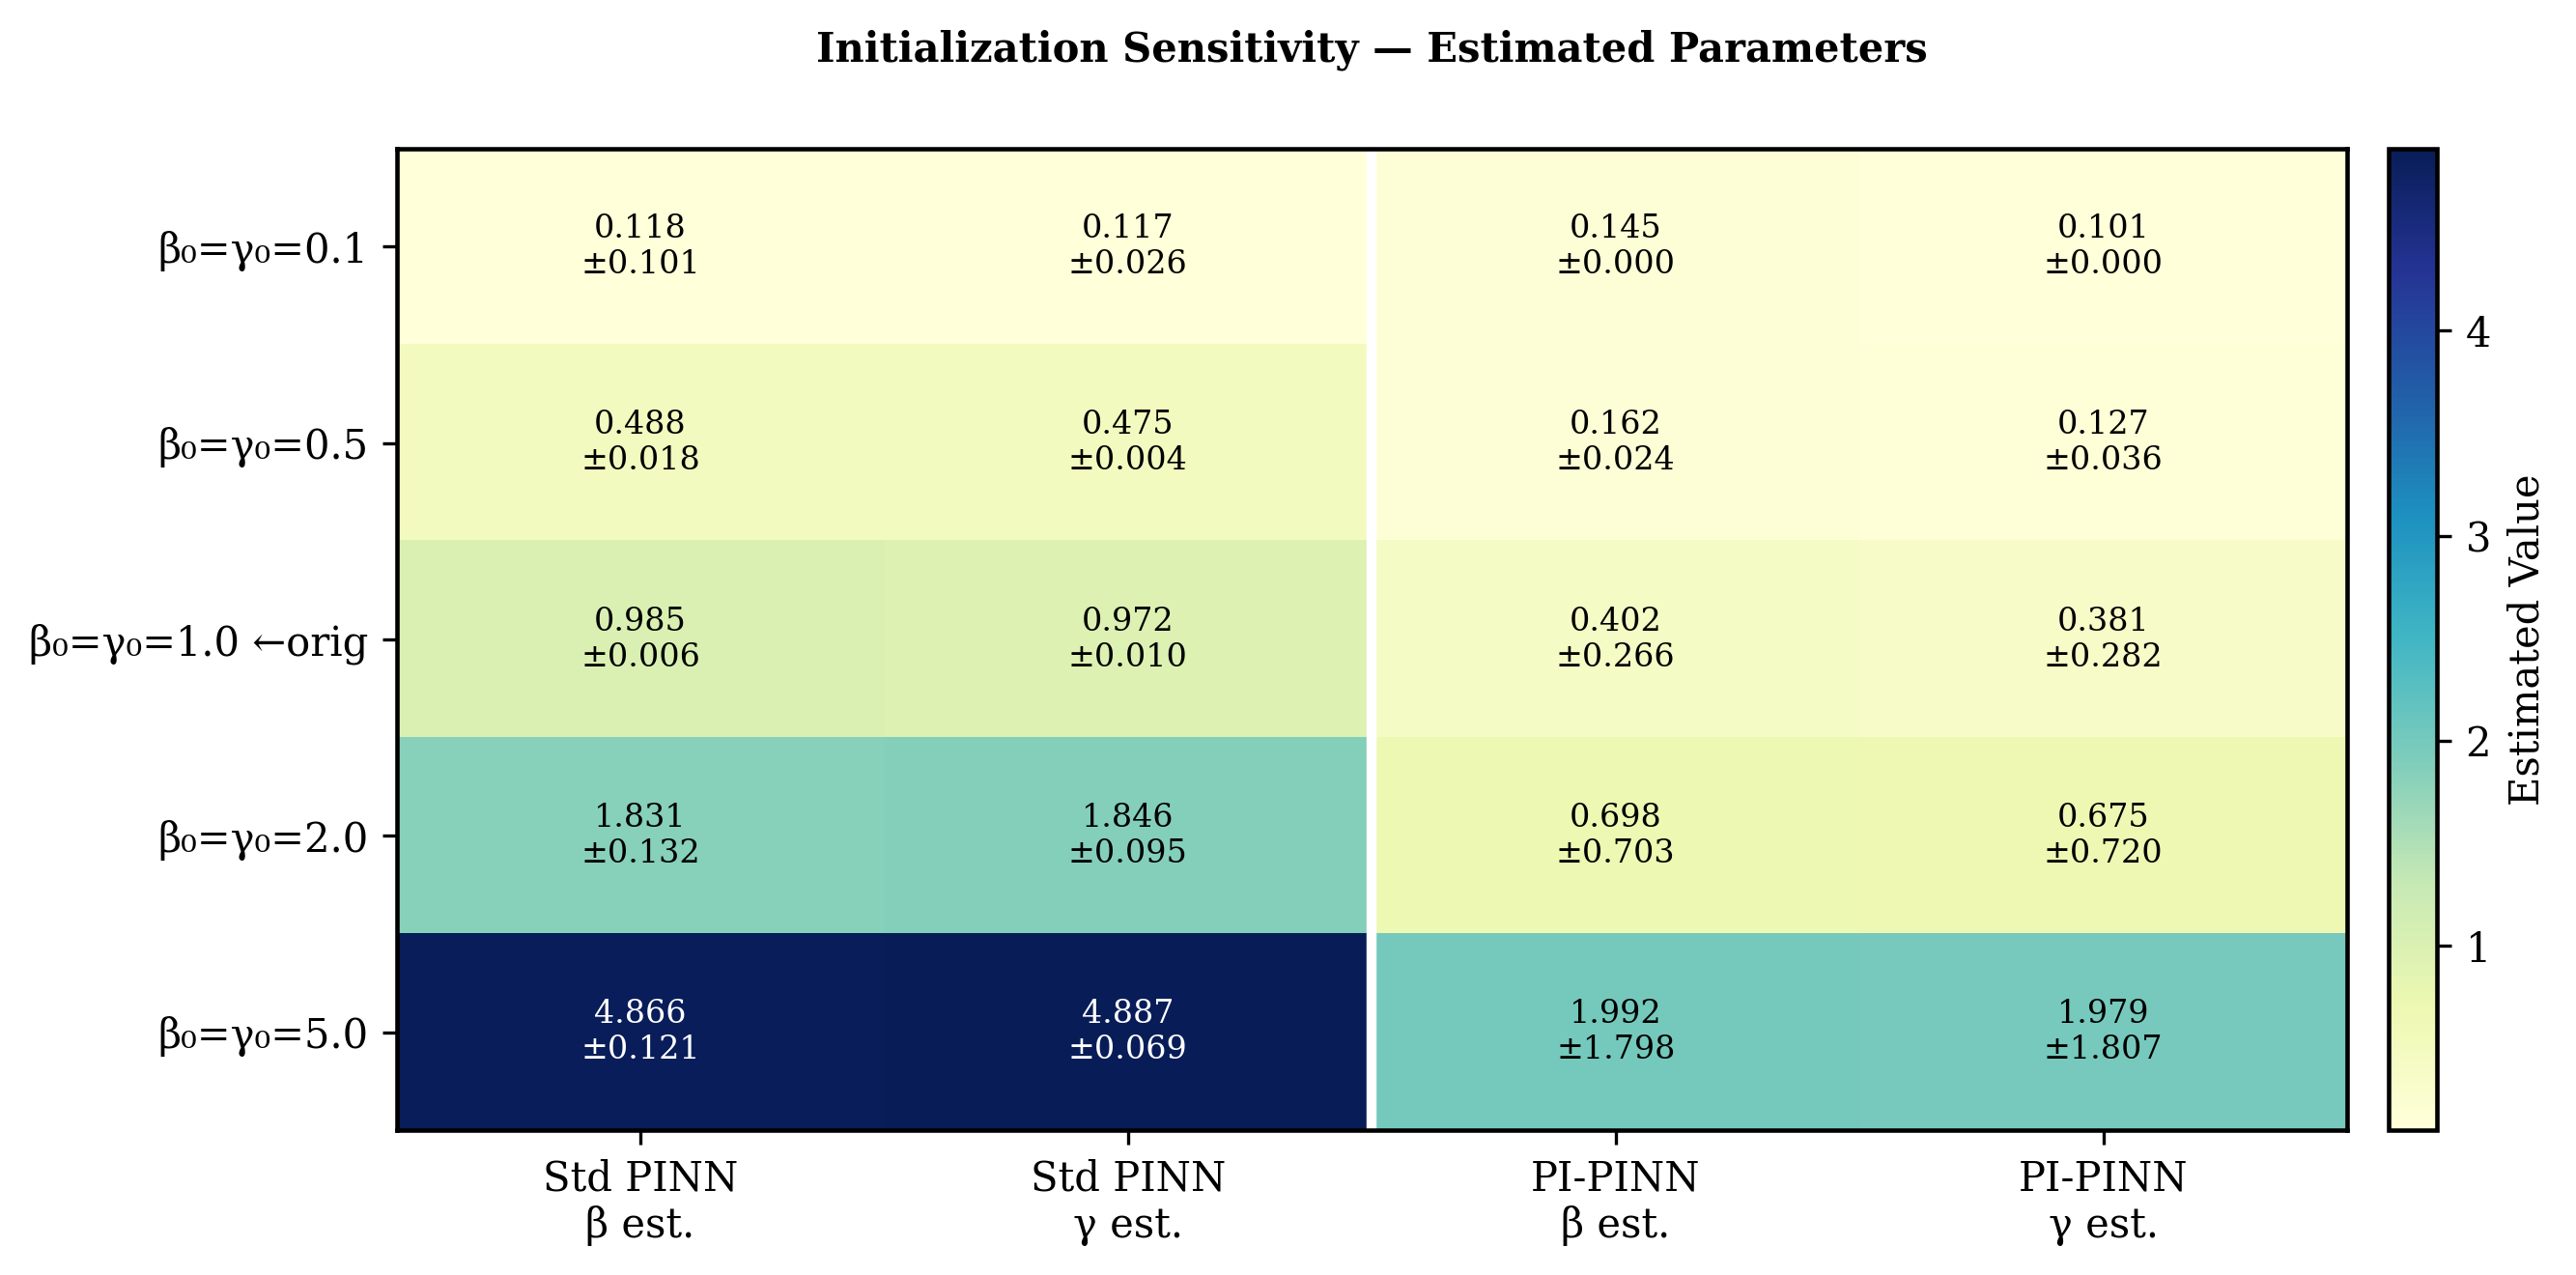

Saved: Fig_Init_Sensitivity_Heatmap_RealData.png


In [12]:
# ══════════════════════════════════════════════════════════════════
# Heatmap: rows = init configs, cols = (PINN beta, PINN gamma, PI-PINN beta, PI-PINN gamma)
# ══════════════════════════════════════════════════════════════════

row_labels = [f'β₀=γ₀={r["b_init"]}' + (' ←orig' if r['is_original'] else '')
              for r in init_results]
col_labels = ['Std PINN\nβ est.', 'Std PINN\nγ est.',
              'PI-PINN\nβ est.',  'PI-PINN\nγ est.']

data_matrix = np.array([
    [r['pinn_beta_mean'], r['pinn_gamma_mean'],
     r['pipinn_beta_mean'], r['pipinn_gamma_mean']]
    for r in init_results
])

std_matrix = np.array([
    [r['pinn_beta_std'], r['pinn_gamma_std'],
     r['pipinn_beta_std'], r['pipinn_gamma_std']]
    for r in init_results
])

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=300)
im = ax.imshow(data_matrix, cmap='YlGnBu', aspect='auto')

ax.set_xticks(range(4))
ax.set_yticks(range(len(init_results)))
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticklabels(row_labels, fontsize=10)

# Add text annotations: mean ± std
for i in range(len(init_results)):
    for j in range(4):
        val = data_matrix[i, j]
        std = std_matrix[i, j]
        text_color = 'white' if val > data_matrix.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}\n±{std:.3f}',
                ha='center', va='center',
                fontsize=8, color=text_color)

# Vertical divider between PINN and PI-PINN
ax.axvline(x=1.5, color='white', linewidth=2.5, linestyle='-')

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Estimated Value', fontsize=10)

ax.set_title('Initialization Sensitivity — Estimated Parameters\n',
              fontsize=10, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('Fig_Init_Sensitivity_Heatmap_RealData.png', dpi=500, bbox_inches='tight')
plt.show()
print('Saved: Fig_Init_Sensitivity_Heatmap_RealData.png')